<a href="https://colab.research.google.com/github/MrMewing/Tugas-Akhir-Prak.Alprog/blob/main/Soal%203%20~Zhofran.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

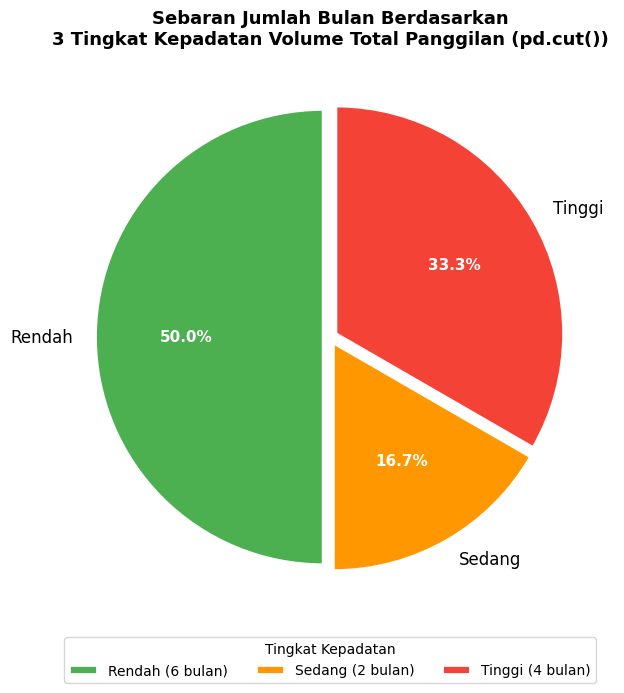

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_excel('Kelas G_Fixed Call Report _rapih.xlsx')

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

# Hitung total panggilan per bulan
monthly_total = df.groupby('Month', observed=True)['Total Number of Calls'].sum().reset_index()
monthly_total.columns = ['Month', 'Total_Calls']

# Bagi ke 3 tingkat kepadatan dengan pd.cut()
monthly_total['Density_Level'] = pd.cut(
    monthly_total['Total_Calls'],
    bins=3,
    labels=['Rendah', 'Sedang', 'Tinggi']
)

# Hitung jumlah bulan per tingkat
density_count = monthly_total.groupby('Density_Level', observed=True).size().reset_index()
density_count.columns = ['Density_Level', 'Jumlah_Bulan']

# Buat Pie Chart
fig4, ax4 = plt.subplots(figsize=(9, 7))

colors = ['#4CAF50', '#FF9800', '#F44336']
wedges, texts, autotexts = ax4.pie(
    density_count['Jumlah_Bulan'],
    labels=density_count['Density_Level'],
    autopct='%1.1f%%',
    colors=colors,
    explode=[0.03, 0.03, 0.03],
    startangle=90,
    textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
    at.set_color('white')

legend_labels = [
    f'{row["Density_Level"]} ({row["Jumlah_Bulan"]} bulan)'
    for _, row in density_count.iterrows()
]
ax4.legend(wedges, legend_labels, title='Tingkat Kepadatan',
           loc='lower center', bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=10)

ax4.set_title(
    'Sebaran Jumlah Bulan Berdasarkan\n3 Tingkat Kepadatan Volume Total Panggilan (pd.cut())',
    fontsize=13, fontweight='bold'
)

plt.tight_layout()
plt.show()